<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter3_pytorch_computer_vision/chapter3_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Thị giác máy tính**

Dược xem là việc dạy mát tính cách để có thể nhìn mọi vật. Lấy ví dụ có thể xây dựng một mô hình để phân loại hình ảnh là chó hay mèo (binary classification), hoặc phân loại xem bức ảnh là chó, mèo hay gà (multi-class classification), hoặc việc xác định xem một chiếc xe có thể xuất hiện ở đâu trong một đoạn phim (object detection), hay việc tìm các bức ảnh về chung một sự vật được biểu diễn khác nhau như thế nào ở đâu (panoptic segmentation)

Xem thêm: [Thị giác máy tính](https://en.wikipedia.org/wiki/Computer_vision), [binary classification](https://developers.google.com/machine-learning/glossary#binary-classification), [multi-class classification](https://developers.google.com/machine-learning/glossary#multi-class-classification), [object detection](https://en.wikipedia.org/wiki/Object_detection), [panoptic segmentation](https://arxiv.org/abs/1801.00868)

# **Thị giác máy tính được sử dụng cho**

Sử dụng trong thiết bị di động, camera và các ứng dụng photo sử dụng thị giác máy tính để nhận diện và sắp xếp hình ảnh, Xe hiện đại sử dụng thị giác máy tính đẻ ngăn chặn va chạm các xe khác và đi đúng đường, doanh nghiệp sử dụng thị giác máy tính để địn nghĩa đếm sản phẩm, camera bảo mật sử dụng thị giác máy tính để nhận diện tác nhân nguy hại


## **0. Thư viện thị giác máy tính trong PyTorch**



- `torchvision:` Lưu trữ bộ dữ liệu, kiến trúc của mô hình và biến đổi hình ảnh thường được sử dụng trong thị giác máy tính
- `torchvision.datasets:` Tìm nhiều ví dụ về thị giác máy tính datasets về phân loại hình ảnh, xác định vật thể, gắn cap cho hình ảnh, phân loại video và có thể tạo nhiều dữ liệu custom (https://docs.pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets)
- `torchvision.models:` Chứa kiến trúc mô hình thị giác máy tính và được sử dụng phổ biến và được triển khai
- `torchvision.transforms:` Thực hiện biến đổi dữ liệu chuyển về số/thực hiện tiền xử lý/augmented trước khi sử dụng mô hình các kỹ thuật xử lý ảnh sẽ được gọi trong đây
- `torch.utils.data.Dataset:` Lớp base cho PyTorch
- `torch.utils.data.DataLoader:` Tạo nhãn lặp cho dữ liệu trong Python (chúng với `torch.utils.data.Dataset`)

Xem thêm: [torchvision](https://docs.pytorch.org/vision/stable/index.html), [torchvision.datasets](https://docs.pytorch.org/vision/stable/datasets.html), [torchvision.models](https://docs.pytorch.org/vision/stable/models.html), [torchvision.transforms](https://docs.pytorch.org/vision/stable/transforms.html), [torch.utils.data.Dataset](https://docs.pytorch.org/docs/2.12/data.html#torch.utils.data.Dataset), [torch.utils.data.DataLoader](https://docs.pytorch.org/docs/2.12/data.html#module-torch.utils.data)

> `torch.utils.data.Dataset` và `torch.utils.data.DataLoader` thường không chỉ sử dụng cho thị giác mà còn có thể sử dụng cho nhiều kiểu dữ liệu khác nhau

In [ ]:
# Thực hiện load dữ liệu

# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

## **1. Lấy bộ dữ liệu**

Để làm việc với bài toán thị giác máy tính, ta cần lấy bộ dữ liệu. Trong bài toán này chính là bộ dữ liệu FashionMNIST (Modified National Institute of Standards and Technology) - bộ dữ liệu chứa hàng ngàn mẫu dữ liệu 10 phụ kiện quần áo khác nhau [ original MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database): là bộ dữ liệu chữ viết tay từ (0 - 9) và được sử dụng cho thị giác máy tính

Nhiệm vụ của ta bây giờ là xây dựng mô hình thị giác máy tính mạng nơ-ron thực hiện việc phân loại hình ảnh. Và Pytorch có hàng tá các datasets trong module `torchvision.datasets` bao gồm cả FashionMNIST trong `torchvision.datasets.FashionMNIST()`

Để tải dữ liệu ta thực hiện:
- `root: str` - dữ liệu khi tải sẽ được lưu ở đâu
- `train: Bool` - có muốn chia training hoặc test không
- `download: Bool` - data nên tải không
- `transform: torchvision.transforms` - Bộ biến đổi nào nên sử dụng cho dữ liệu
- `target_transform` - ta có thể biến đổi target (nhãn)

In [ ]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

In [ ]:
# See first training sample
image, label = train_data[0]
image, label

### **Shape của đầu vào và đầu ra của mô hình thị giác máy tính**


Ta có một tensor lớn chứa các giá trị của ảnh cùng với đó là một giá trị duy nhất chính là target hay nhãn của ảnh đó

In [ ]:
# What's the shape of the image?
image.shape

Shape của hifnha rnh là `[1, 28, 28]` điều này cho biết

```
[color_channels = 1, height = 28, width = 28]
```

Có `color_channels = 1` tức là hình có một màu duy nhát (xám)


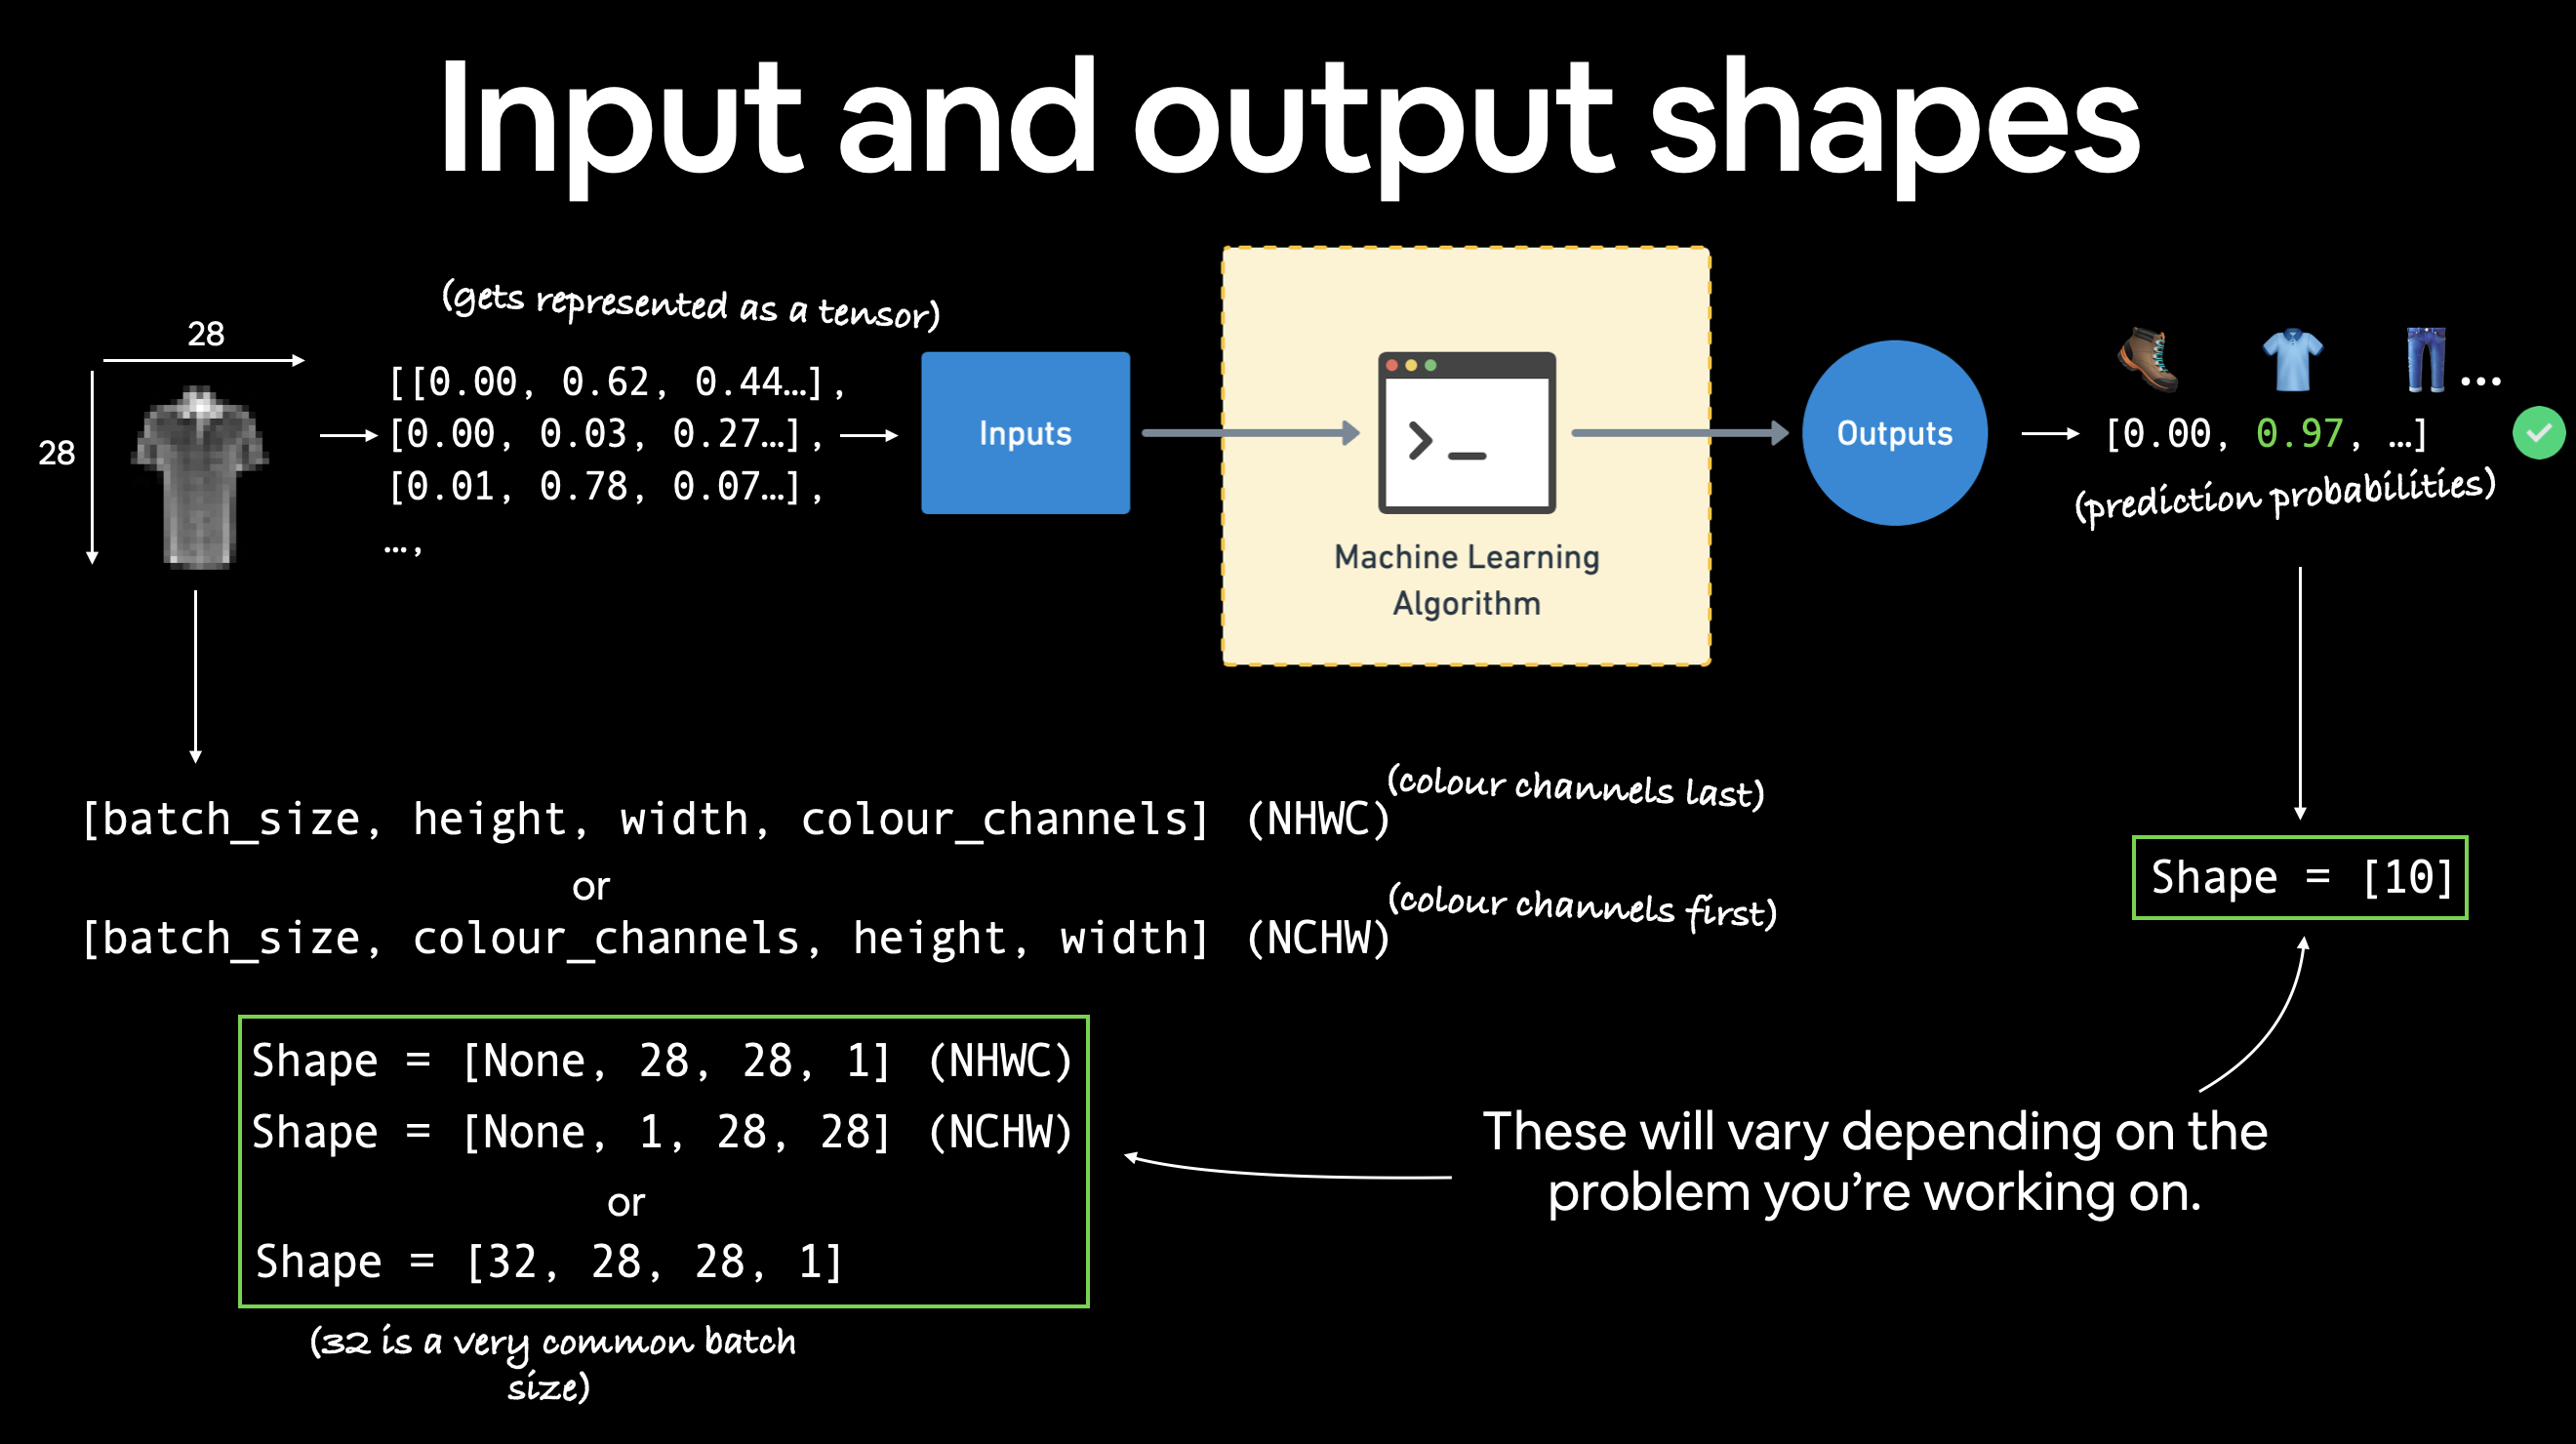

In [3]:
from PIL import Image

duong_dan = '03-computer-vision-input-and-output-shapes.png'
img = Image.open(duong_dan)
img

*Các bài toán khác nhau sẽ có những dạng đầu vào khác nhau. Nhưng vẫn dữ liệu cách thức từ mã hóa dữ liệu thành những con số, xây dựng một mô hinh để tìm các mẫu trong những con số đó, chuyền mẫu đó thành những thứ có nghĩa*

Nếu `color_channels = 3` tức hình cảu ta có tới 3 giá trị pixel của đỏ, xanh lá, xanh nước biển (hay nói cách khác là mã [RGB](https://en.wikipedia.org/wiki/RGB_color_model)).

Tensor sẽ được biểu diễn đối với một dữ liệu hình ảnh theo quy tắc `CHW` (Color Channels, Height, Width) và hình ảnh cũng nên được biểu diễn bằng việc `CHW` hay `HWC`

> Tuy nhiên ta cũng sẽ thấy `NCHW` và `NHWC` với `N` biểu diễn cho số lượng ảnh. Láy ví dụ ta chọn `batch_size=32` thì tensor sẽ có shape [32, 1, 28, 28]

PyTorch sẽ biểu diễn tensor ảnh theo quy tắc `NCHW` (color_channels đầu tiên) tuy nhiên tốt hơn hết là nên thep quy tắc `NHWC`. Đối với dữ liệu mẫu nhỏ thì không thấy rõ sự khác biệt nhưng khi làm với mẫu lớn cũng như mạng CNN ta sẽ thấy rõ hơn

Xem thêm: https://pytorch.org/blog/tensor-memory-format-matters/#pytorch-best-practice (format nào tensor trong xử lý ảnh là tốt)

In [ ]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

In [ ]:
# See classes
class_names = train_data.classes
class_names

Vậy ta đã có 60000 mẫu huấn luyện mô hình và 10000 mẫu để testing và cũng đó có 10 nhãn khác nhau đây chính là một bài toán **multi-class classification**

### **Trực quan hóa dữ liệu**

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label);

Ta cũng có thể chuyển mã màu này về màu xám dùng `cmap` của `plt.imshow()`

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

Ta sẽ thực hiện việc xây dựng mô mô hình phân loại hình ảnh trong thị giác máy tính, bằng cách lấy các giá trị pixels của hình ảnh để tìm patterns của chúng khi xuất hiện một hình ảnh mới

> **Câu hỏi:** Những dữ liệu này là một dạng dữ liệu phi tuyến rời rạc

## **2. Chuẩn bị DataLoader**

